Objective is to _"write some code simulating a poisson process"_

Starting here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html

A Poisson process models random events occurring in time (or space) where:
- Events occur independently
- The average rate of events is constant: 𝜆
- Number of events through time N(t)

Note that there is a difference between a Poisson process and a compound Poisson process

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import fractions
import scipy
from matplotlib.collections import LineCollection
import jump_process # dans .py 
from scipy.stats import poisson

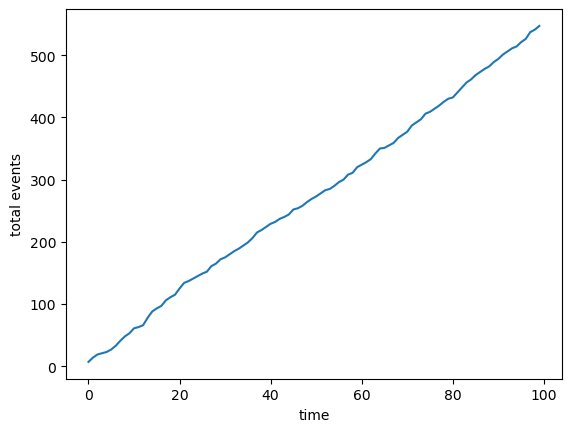

In [29]:
# rate 
lam = 5

# number of time intervals
T = 100

# simulate counts per interval
    #rvs(mu, loc=0, size=1, random_state=None)
events = poisson.rvs(mu=lam, size=T) # random variates 

# cumulative number of events
cumulative_events = np.cumsum(events)

plt.plot(cumulative_events)
plt.xlabel("time")
plt.ylabel("total events")
plt.show()

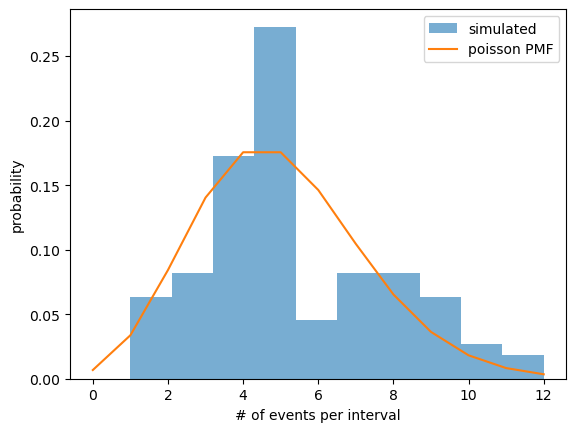

theoretical mean: 5.0
theoretical variance: 5.0
theoretical std: 2.23606797749979
theoretical median: 5.0


In [32]:
#looking at a probability mass function 
# possible event counts
k = np.arange(0, max(events)+1)

# theoretical PMF
pmf = poisson.pmf(k, mu=lam)

# histogram of simulated data
plt.hist(events, bins= 10, density=True, alpha=0.6, label="simulated")

# theoretical PMF
plt.plot(k, pmf, '-', label="poisson PMF")
plt.xlabel("# of events per interval")
plt.ylabel("probability")
plt.legend()
plt.show()

print("theoretical mean:", poisson.mean(mu=lam))
print("theoretical variance:", poisson.var(mu=lam))
print("theoretical std:", poisson.std(mu=lam))
print("theoretical median:", poisson.median(mu=lam))

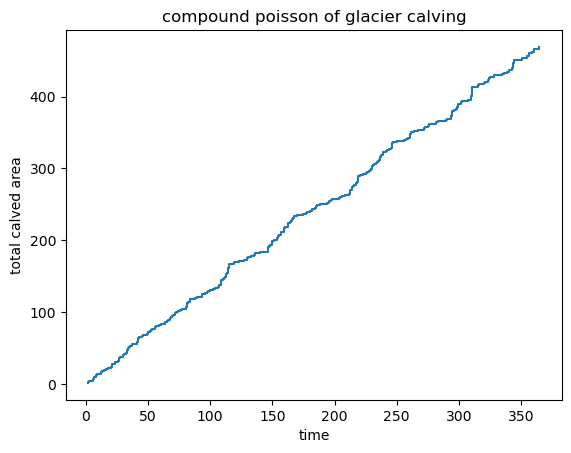

In [ ]:
# so for glacial calving
#  if there is 1 event per day and we look at 365 days

L = 1 # event per day
T = 365 # days

# number of events 
N = np.random.poisson(L * T) #total number of calving events in a year

# event times - randomly distributed in the year
event_times = np.sort(np.random.uniform(0, T, N))

# glacier size
sizes = np.random.lognormal(mean=0, sigma=0.8, size = N)

# cumulative calved area
calved_area = np.cumsum(sizes)

plt.step(event_times, calved_area)
plt.xlabel("time")
plt.ylabel("total calved area")
plt.title("compound poisson of glacier calving")
plt.show()

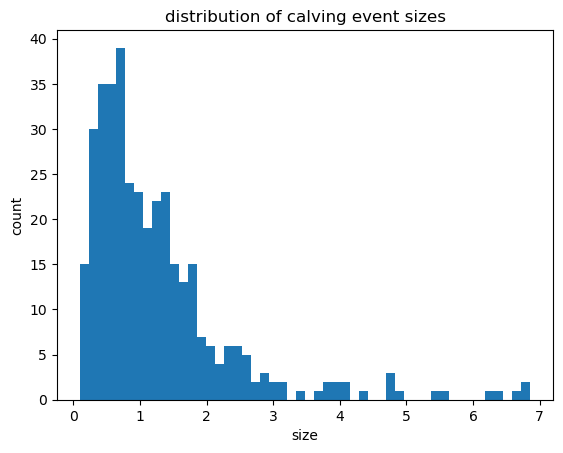

In [36]:
plt.hist(sizes, bins=50)
plt.xlabel("size")
plt.ylabel("count")
plt.title("distribution of calving event sizes")
plt.show()